<a href="https://colab.research.google.com/github/KEERTHANASRI-A-M-0609/keerthanasri-codeboosters-2026/blob/main/Day%205/Mini_Project_Day_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weather Intelligence System

## Import Libraries

In [ ]:
import os
import requests
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Configuration
CSV_PATH = 'weather_data.csv'
API_KEY = '6478714fc80d6790733d043606116975'
CITIES = ['London', 'New York', 'Tokyo', 'Paris', 'Mumbai', 'Sydney', 'Cairo']

def load_or_fetch_data():
    if os.path.exists(CSV_PATH):
        print("--- Loading data from existing Day 3 CSV ---")
        return pd.read_csv(CSV_PATH)
    else:
        print("--- CSV not found. Fetching live data from OpenWeather API ---")
        weather_list = []
        for city in CITIES:
            url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"
            response = requests.get(url)
            if response.status_code == 200:
                data = response.json()
                weather_list.append({
                    'city': data['name'],
                    'temperature': data['main']['temp'],
                    'humidity': data['main']['humidity'],
                    'wind_speed': data['wind']['speed']
                })
        return pd.DataFrame(weather_list)

df_raw = load_or_fetch_data()
print(df_raw.head())

--- CSV not found. Fetching live data from OpenWeather API ---
       city  temperature  humidity  wind_speed
0    London        25.10        45        3.60
1  New York        12.87        55        8.23
2     Tokyo        24.10        63        9.77
3     Paris        29.47        48        1.54
4    Mumbai        33.99        59        9.26


## Data Extraction

In [ ]:
API_KEY = "6478714fc80d6790733d043606116975"
CITIES = ['Chennai', 'Bangalore', 'Hyderabad', 'Mumbai', 'Delhi']

In [ ]:
def load_or_fetch_data():
    print("--- Fetching live data from OpenWeather API ---")
    weather_list = []
    for city in CITIES:
        url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            weather_list.append({
                'city': data['name'],
                'temperature': data['main']['temp'],
                'humidity': data['main']['humidity'],
                'pressure': data['main']['pressure'],
                'wind_speed': data['wind']['speed'],
                'weather_condition': data['weather'][0]['description'],
                'datetime': pd.to_datetime(data['dt'], unit='s') # Convert Unix timestamp to datetime
            })
        else:
            print(f"Error fetching data for {city}: {response.status_code} - {response.text}")
    return pd.DataFrame(weather_list)

In [ ]:
df_raw = load_or_fetch_data()
print("Raw Data Head:")
display(df_raw.head())

--- Fetching live data from OpenWeather API ---
Raw Data Head:


,city,temperature,humidity,pressure,wind_speed,weather_condition,datetime
0,Chennai,33.57,60,1005,4.12,scattered clouds,2026-05-30 10:02:13
1,Bengaluru,31.28,56,1009,4.12,scattered clouds,2026-05-30 10:05:03
2,Hyderabad,37.23,28,1008,7.20,scattered clouds,2026-05-30 10:05:16
3,Mumbai,33.99,59,1008,9.26,haze,2026-05-30 09:58:57
4,Delhi,35.05,36,1001,3.09,few clouds,2026-05-30 10:07:31


## Data Cleaning

In [ ]:
print(f"Original row count: {len(df_raw)}")
# Missiing Values
missing_before = df_raw.isnull().sum().sum()
df_cleaned = df_raw.dropna().copy() #
missing_after = df_cleaned.isnull().sum().sum()
print(f"Missing values removed: {missing_before - missing_after}")
print(f"Missing value count: {missing_after}")

# Remove Duplicates
duplicate_before = df_cleaned.duplicated().sum()
df_cleaned.drop_duplicates(inplace=True)
duplicate_after = df_cleaned.duplicated().sum()
print(f"Duplicate records removed: {duplicate_before - duplicate_after}")
print(f"Duplicate count: {duplicate_after}")

print(f"Final row count: {len(df_cleaned)}")
print("\nCleaned Data Head:")
display(df_cleaned.head())

Original row count: 5
Missing values removed: 0
Missing value count: 0
Duplicate records removed: 0
Duplicate count: 0
Final row count: 5

Cleaned Data Head:


,city,temperature,humidity,pressure,wind_speed,weather_condition,datetime
0,Chennai,33.57,60,1005,4.12,scattered clouds,2026-05-30 10:02:13
1,Bengaluru,31.28,56,1009,4.12,scattered clouds,2026-05-30 10:05:03
2,Hyderabad,37.23,28,1008,7.20,scattered clouds,2026-05-30 10:05:16
3,Mumbai,33.99,59,1008,9.26,haze,2026-05-30 09:58:57
4,Delhi,35.05,36,1001,3.09,few clouds,2026-05-30 10:07:31


## ETL Pipeline

In [ ]:
CSV_CLEANED_PATH = 'weather_cleaned.csv'
df_cleaned.to_csv(CSV_CLEANED_PATH, index=False)
print(f"Cleaned data saved to {CSV_CLEANED_PATH}")

Cleaned data saved to weather_cleaned.csv


## SQL Storage

In [ ]:
DB_PATH = 'weather.db'
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

cursor.execute('''
    CREATE TABLE IF NOT EXISTS weather_data (
        city TEXT,
        temperature REAL,
        humidity INTEGER,
        pressure INTEGER,
        wind_speed REAL,
        weather_condition TEXT,
        datetime TEXT
    )
''')
conn.commit()

# Load data
df_cleaned.to_sql('weather_data', conn, if_exists='replace', index=False)
print(f"Cleaned data loaded into {DB_PATH} table 'weather_data'")

conn.close()
print("SQLite connection closed.")

Cleaned data loaded into weather.db table 'weather_data'
SQLite connection closed.


## SQL Analysis

In [ ]:
DB_PATH = 'weather.db'
conn = sqlite3.connect(DB_PATH)
query_1 = pd.read_sql_query("SELECT * FROM weather_data", conn)
print("Query 1: All records")
display(query_1)

Query 1: All records


,city,temperature,humidity,pressure,wind_speed,weather_condition,datetime
0,Chennai,33.57,60,1005,4.12,scattered clouds,2026-05-30 10:02:13
1,Bengaluru,31.28,56,1009,4.12,scattered clouds,2026-05-30 10:05:03
2,Hyderabad,37.23,28,1008,7.20,scattered clouds,2026-05-30 10:05:16
3,Mumbai,33.99,59,1008,9.26,haze,2026-05-30 09:58:57
4,Delhi,35.05,36,1001,3.09,few clouds,2026-05-30 10:07:31


In [ ]:
query_2 = pd.read_sql_query("SELECT city, AVG(temperature) as avg_temperature FROM weather_data GROUP BY city", conn)
print("\nQuery 2: Average temperature by city")
display(query_2)


Query 2: Average temperature by city


,city,avg_temperature
0,Bengaluru,31.28
1,Chennai,33.57
2,Delhi,35.05
3,Hyderabad,37.23
4,Mumbai,33.99


In [ ]:
query_3 = pd.read_sql_query("SELECT city, humidity FROM weather_data ORDER BY humidity DESC LIMIT 1", conn)
print("\nQuery 3: City with highest humidity")
display(query_3)


Query 3: City with highest humidity


,city,humidity
0,Chennai,60


In [ ]:
query_4 = pd.read_sql_query("SELECT city, wind_speed FROM weather_data ORDER BY wind_speed DESC LIMIT 1", conn)
print("\nQuery 4: City with highest wind speed")
display(query_4)


Query 4: City with highest wind speed


,city,wind_speed
0,Mumbai,9.26


In [ ]:
query_5 = pd.read_sql_query("SELECT weather_condition, COUNT(*) as count FROM weather_data GROUP BY weather_condition", conn)
print("\nQuery 5: Weather condition count")
display(query_5)
conn.close()
print("SQLite connection closed.")


Query 5: Weather condition count


,weather_condition,count
0,few clouds,1
1,haze,1
2,scattered clouds,3


SQLite connection closed.


## Data Visualization

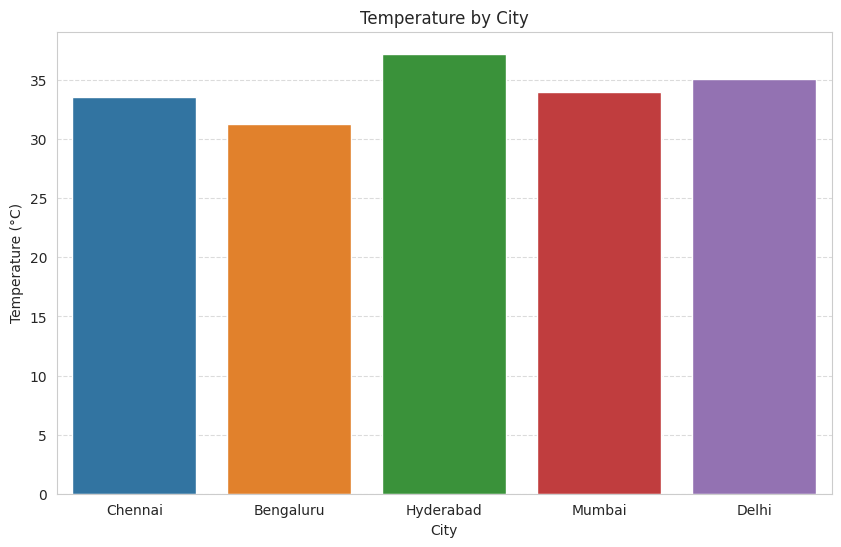

In [ ]:
df_viz = pd.read_csv(CSV_CLEANED_PATH)

plt.figure(figsize=(10, 6))
sns.barplot(x='city', y='temperature', data=df_viz, palette='tab10', hue='city', legend=False)
plt.title('Temperature by City')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

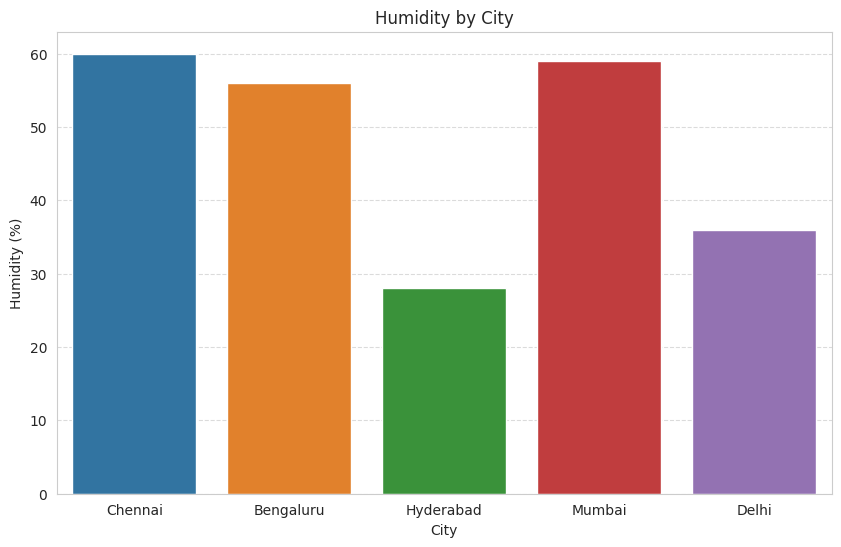

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='city', y='humidity', data=df_viz, palette='tab10', hue='city', legend=False)
plt.title('Humidity by City')
plt.xlabel('City')
plt.ylabel('Humidity (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

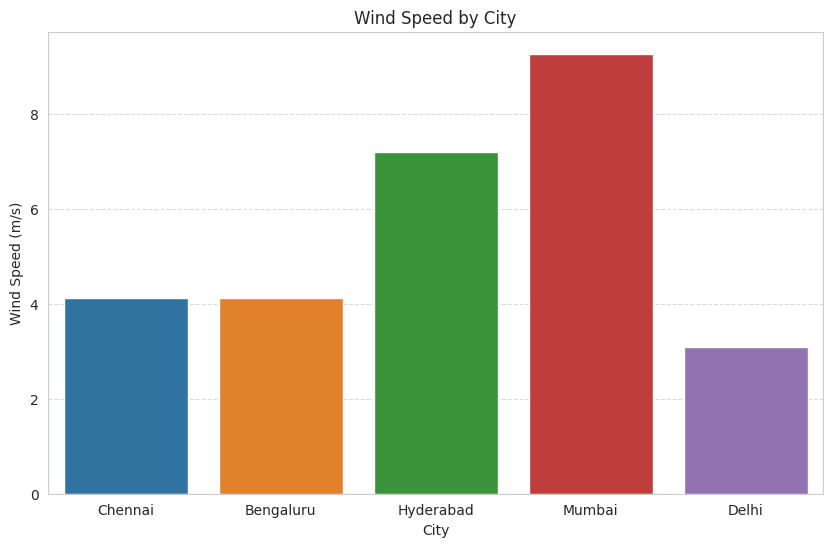

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='city', y='wind_speed', data=df_viz, palette='tab10', hue='city', legend=False)
plt.title('Wind Speed by City')
plt.xlabel('City')
plt.ylabel('Wind Speed (m/s)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

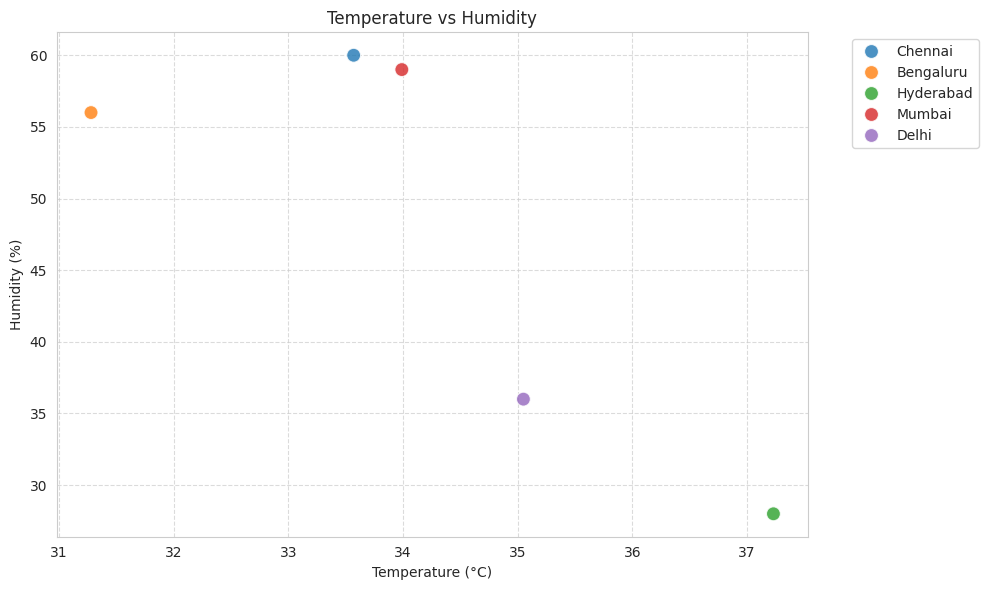

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temperature', y='humidity', data=df_viz, hue='city', s=100, alpha=0.8, palette='tab10')
plt.title('Temperature vs Humidity')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Machine Learning Prediction

Training data size: 3
Testing data size: 2

Mean Absolute Error (MAE): 17.44
R-squared (R²): -2.63
Root Mean Squared Error (RMSE): 19.05

Actual vs Predicted Humidity:


,Actual Humidity,Predicted Humidity
1,56,81.097678
4,36,45.789814


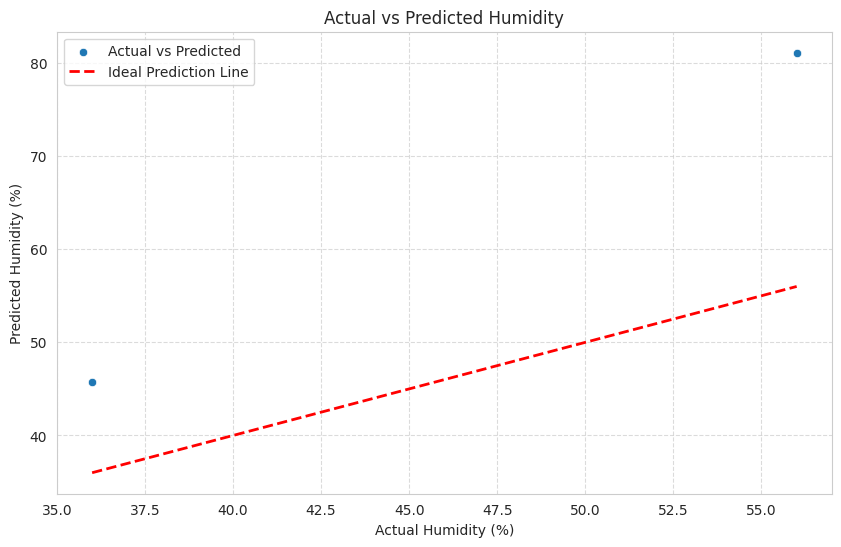

In [ ]:
X = df_viz[['temperature', 'wind_speed']]
y = df_viz['humidity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

print(f"Training data size: {len(X_train)}")
print(f"Testing data size: {len(X_test)}")

#Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nMean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R²): {r2:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
results_df = pd.DataFrame({'Actual Humidity': y_test, 'Predicted Humidity': y_pred})
print("\nActual vs Predicted Humidity:")
display(results_df)

#scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, label='Actual vs Predicted')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2, label='Ideal Prediction Line') # Ideal prediction line
plt.title('Actual vs Predicted Humidity')
plt.xlabel('Actual Humidity (%)')
plt.ylabel('Predicted Humidity (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()